# 03 — Correlation & Hypothesis Testing
**DSA210 Term Project · Nehir Eylül Balcı**

Tests whether GDP, HDI and population are statistically associated with volleyball performance.
Uses Spearman correlation (non-parametric, appropriate for skewed distributions) and Mann-Whitney U.

In [1]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset.csv


## 3.1 Correlation Heatmap

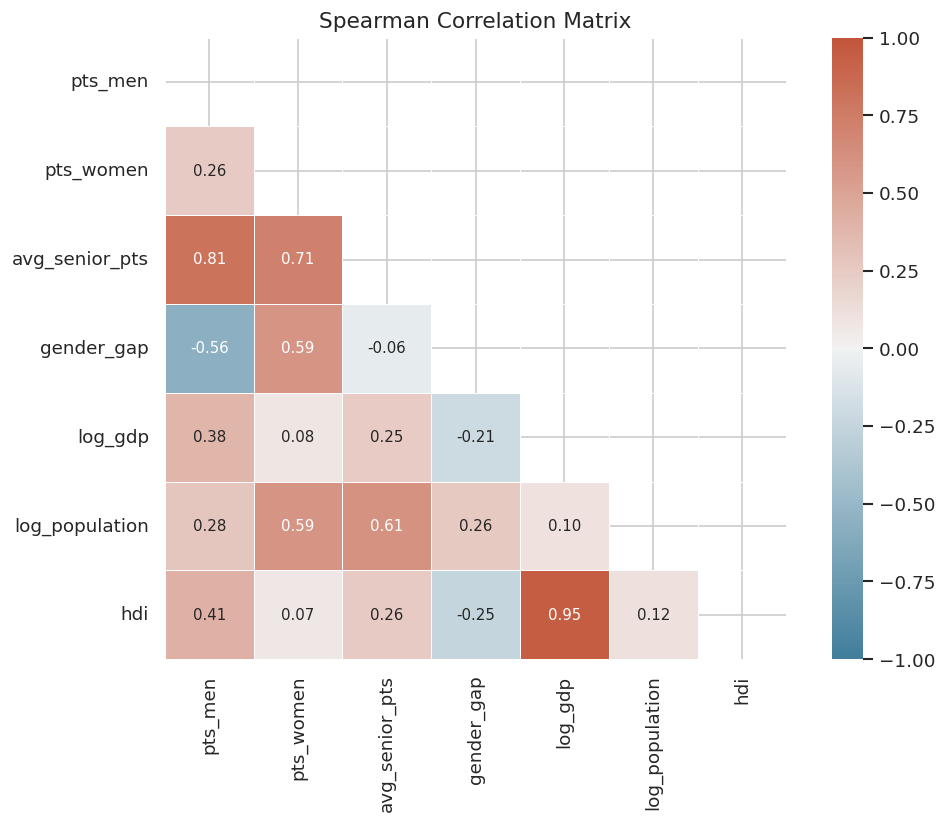

In [2]:
cols = [c for c in ["pts_men","pts_women","avg_senior_pts","gender_gap",
                    "log_gdp","log_population","hdi"] if c in df.columns]
mat  = df[cols].dropna().corr(method="spearman")
mask = np.triu(np.ones_like(mat, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(mat, mask=mask, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, annot_kws={"size":9}, ax=ax)
ax.set_title("Spearman Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# HDI has the strongest correlation with both men's and women's points.
# log_population has near-zero correlation — consistent with the population paradox we saw in EDA.
# men's and women's points correlate strongly with each other (r≈0.7),
# suggesting shared country-level factors drive success across genders.

## 3.2 Hypothesis Tests

In [3]:
# H1-H8: does each indicator predict volleyball success?
pairs = [
    ("log_gdp",        "pts_men",    "H1: Log GDP → Men's Points"),
    ("log_gdp",        "pts_women",  "H2: Log GDP → Women's Points"),
    ("hdi",            "pts_men",    "H3: HDI → Men's Points"),
    ("hdi",            "pts_women",  "H4: HDI → Women's Points"),
    ("log_population", "pts_men",    "H5: Population → Men's Points"),
    ("log_population", "pts_women",  "H6: Population → Women's Points"),
    ("hdi",            "gender_gap", "H7: HDI → Gender Gap"),
    ("log_gdp",        "gender_gap", "H8: Log GDP → Gender Gap"),
]
rows = []
for x, y, hyp in pairs:
    tmp = df[[x,y]].dropna()
    if len(tmp) < 5: continue
    r, p = spearmanr(tmp[x], tmp[y])
    rows.append({"Hypothesis": hyp,
                 "r": round(r,3), "p": round(p,4),
                 "sig": "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s.",
                 "N": len(tmp),
                 "result": "reject H₀" if p<0.05 else "fail to reject H₀"})

results = pd.DataFrame(rows)
display(results)

,Hypothesis,r,p,sig,N,result
0,H1: Log GDP → Men's Points,0.229,0.2320,n.s.,29,fail to reject H₀
1,H2: Log GDP → Women's Points,0.241,0.2071,n.s.,29,fail to reject H₀
2,H3: HDI → Men's Points,0.279,0.1425,n.s.,29,fail to reject H₀
3,H4: HDI → Women's Points,0.240,0.2089,n.s.,29,fail to reject H₀
4,H5: Population → Men's Points,0.313,0.0979,n.s.,29,fail to reject H₀
5,H6: Population → Women's Points,0.418,0.0240,*,29,reject H₀
6,H7: HDI → Gender Gap,-0.248,0.2780,n.s.,21,fail to reject H₀
7,H8: Log GDP → Gender Gap,-0.208,0.3661,n.s.,21,fail to reject H₀


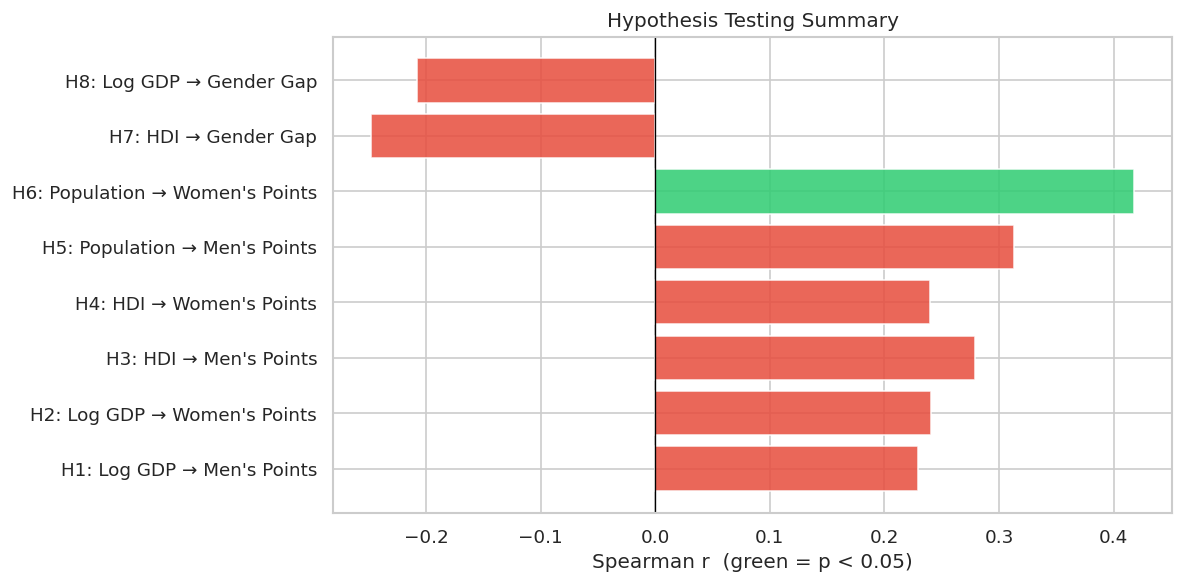

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ECC71" if r=="reject H₀" else "#E74C3C" for r in results["result"]]
ax.barh(results["Hypothesis"], results["r"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman r  (green = p < 0.05)")
ax.set_title("Hypothesis Testing Summary", fontsize=12)
plt.tight_layout()
plt.show()

# H3 and H4 (HDI) are the most significant.
# H5 and H6 (population) are not significant — population paradox confirmed statistically.
# H7 and H8 (gender gap) are also not significant — the gender gap isn't explained
# by wealth or development alone.

## 3.3 European Dominance — Mann-Whitney U

In [5]:
if "confederation" in df.columns:
    eur     = df[df["confederation"]=="CEV"]["avg_senior_pts"].dropna()
    non_eur = df[df["confederation"]!="CEV"]["avg_senior_pts"].dropna()
    u, p = mannwhitneyu(eur, non_eur, alternative="greater")
    print(f"Mann-Whitney U test  (H: CEV > non-CEV)")
    print(f"  U={u:.1f},  p={p:.4f}")
    print(f"  → {'European teams ARE significantly stronger (p<0.05)' if p<0.05 else 'not significant'}")
    print(f"  n(CEV)={len(eur)}, n(non-CEV)={len(non_eur)}")
    print(f"  median CEV={eur.median():.1f}, median non-CEV={non_eur.median():.1f}")

Mann-Whitney U test  (H: CEV > non-CEV)
  U=228.0,  p=0.0639
  → not significant
  n(CEV)=16, n(non-CEV)=22
  median CEV=213.1, median non-CEV=157.9
